In [1]:
import pandas as pd
import numpy as np

In [7]:
data = pd.read_csv("eda-data.csv")
data.head()

,SWANID,AGE,RACE(1) Black/African American,RACE(2) Chinese/Chinese American,RACE(3) Japanese/Japanese American,DEGREE,DIABETE0,PHYSACT0,MARITAL0,HEIGHT0,...,SMOKERE10,DRNKBEE10,DEPRESSION10,ANXIETY10,D_HORMUSER10,HORMUSER10,C_SPBMDT10,SPBMDT10,C_HPBMDT10,HPBMDT10
0,10046,52,0,1,0,1,0,4,1,156.0,...,0.0,0.0,16.0,0.0,0.0,1.0,0.0,1.163358,0.0,1.034961
1,10056,51,0,0,0,2,0,2,1,161.7,...,0.0,1.0,12.0,0.0,0.0,0.0,0.0,0.894210,0.0,0.847180
2,10092,45,0,0,0,2,0,2,1,167.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10153,51,0,0,1,1,0,3,1,149.4,...,0.0,0.0,12.0,2.0,0.0,0.0,0.0,1.007640,0.0,0.983010
4,10196,46,0,1,0,4,0,2,1,153.4,...,0.0,0.0,14.0,3.0,0.0,0.0,0.0,0.831566,0.0,0.767219


In [8]:
data.shape

(1804, 190)

# Check NaNs

<Axes: >

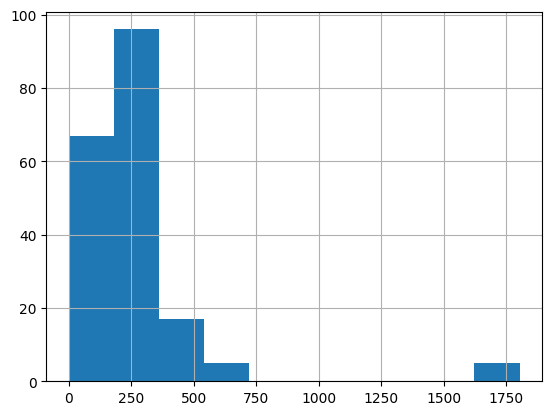

In [9]:
data.isna().sum().hist()

In [25]:
data.isna().sum().sort_values(ascending=False)[100:120]

HORMUSER5      208
HEIGHT3        207
C_HPBMDT5      200
DEPRESSION4    200
C_SPBMDT5      200
D_HORMUSER5    200
SMOKERE4       196
MARITAL6       193
DIABETE6       190
STATUS6        188
INSULIN6       188
HORMUSER6      188
HPBMDT2        187
D_HORMUSER6    185
C_HPBMDT6      185
C_SPBMDT6      185
SPBMDT2        185
MARITAL4       185
INSULIN4       184
HORMUSER4      184
dtype: int64

We can see that most of the nulls are in the outcome: HPBMDT, SPBMDT for visits 4-10. Then, exposure HORMUSER10 is the next most missing. We can also see that HPBMDT and SPBMDT do not have the same amount of nulls per visit. It's kind of random which ones had more nulls than the other: more nulls in HPBMDT for visits 2, 6, 7, 8, 9, 10; more nulls in SPBMDT for visits 1, 3, 4, 5.

Also, all HORMUSER's are below the HPBMDT, SPBMDT for each visit. This means, there are more individuals with unknown outcome than unknown exposure at each visit. We now investigate whether this is true for all individuals. 

## Check NaN discrepancy between exposure and outcome.
Do we need to separate censoring for exposure and outcome?

In [15]:
short_col = data.columns[data.isnull().any(axis=0)].tolist()[2:]

In [16]:
# Among those with at least one null, how many had a null exposure but not null outcome, and vice versa for each visit?
# e.g. for visit 1, all individuals had exposure, 78/81 had null outcomes. 

# 1,804 out of 1,804 rows have at least one null
data_w_null = data[data.isnull().any(axis=1)][short_col]
data_w_null.shape

(1804, 163)

In [26]:
data_w_null

,MARITAL1,HEIGHT1,WEIGHT1,STATUS1,SMOKERE1,DRNKBEE1,DEPRESSION1,ANXIETY1,SPBMDT1,HPBMDT1,...,SMOKERE10,DRNKBEE10,DEPRESSION10,ANXIETY10,D_HORMUSER10,HORMUSER10,C_SPBMDT10,SPBMDT10,C_HPBMDT10,HPBMDT10
0,1.0,155.4,74.0,6.0,0.0,0.0,17.0,1.0,1.1277,0.9619,...,0.0,0.0,16.0,0.0,0.0,1.0,0.0,1.163358,0.0,1.034961
1,1.0,161.3,53.2,3.0,0.0,1.0,16.0,1.0,0.9140,0.8499,...,0.0,1.0,12.0,0.0,0.0,0.0,0.0,0.894210,0.0,0.847180
2,1.0,166.1,85.6,3.0,0.0,1.0,13.0,1.0,1.0377,0.8412,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,149.5,68.0,3.0,0.0,0.0,13.0,1.0,1.0673,1.0313,...,0.0,0.0,12.0,2.0,0.0,0.0,0.0,1.007640,0.0,0.983010
4,1.0,153.6,49.1,3.0,0.0,0.0,12.0,0.0,0.9806,0.7968,...,0.0,0.0,14.0,3.0,0.0,0.0,0.0,0.831566,0.0,0.767219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799,1.0,158.6,81.8,3.0,0.0,1.0,17.0,1.0,NaN,NaN,...,0.0,1.0,17.0,2.0,0.0,0.0,1.0,NaN,1.0,NaN
1800,1.0,161.4,78.3,6.0,0.0,1.0,14.0,2.0,1.1747,1.0018,...,0.0,1.0,17.0,2.0,0.0,0.0,0.0,1.199120,0.0,0.999020
1801,2.0,166.0,84.8,3.0,1.0,1.0,19.0,4.0,1.1394,1.0013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1802,1.0,159.0,73.6,6.0,1.0,0.0,44.0,6.0,1.0116,0.9056,...,1.0,0.0,42.0,15.0,0.0,1.0,0.0,0.910560,0.0,0.763750


In [29]:
# visit 2
# HORMUSER2: 105
# SPBMDT2: 185
# HPBMDT2: 187
visit2 = data_w_null.loc[:, ['HORMUSER2', 'SPBMDT2', 'HPBMDT2']]
visit2

,HORMUSER2,SPBMDT2,HPBMDT2
0,1.0,1.134700,0.976400
1,0.0,0.893400,0.840700
2,NaN,NaN,NaN
3,0.0,1.047900,1.023800
4,0.0,0.974400,0.784100
...,...,...,...
1799,0.0,1.253886,1.377238
1800,0.0,1.170600,1.008700
1801,NaN,NaN,NaN
1802,0.0,1.027800,0.875900


In [30]:
# visit 2: 1 individual with null exposure, but measured outcome
visit2_temp = visit2[visit2['HORMUSER2'].isna()].notna()
visit2_temp[visit2_temp['SPBMDT2'] | visit2_temp['HPBMDT2']].shape[0]

1

In [31]:
# visit 2: 86 individuals with measured exposure, null SPBMDT2
# visit 2: 5 individuals with measured HPBMDT2, null SPBMDT2
visit2[visit2['SPBMDT2'].isna()].notna().sum()

HORMUSER2    81
SPBMDT2       0
HPBMDT2       5
dtype: int64

In [32]:
# visit 2: 89 individuals with measured exposure, null HPBMDT2
# visit 2: 8 individuals with measured SPBMDT2, null HPBMDT2
visit2[visit2['HPBMDT2'].isna()].notna().sum()

HORMUSER2    83
SPBMDT2       7
HPBMDT2       0
dtype: int64

In [33]:
# visit 2: 81 individuals with measured exposure, null SPBMDT2 & HPBMDT2
visit2[visit2['SPBMDT2'].isna() & visit2['HPBMDT2'].isna()].notna().sum()

HORMUSER2    76
SPBMDT2       0
HPBMDT2       0
dtype: int64

In [34]:
# visit 2: 94 individuals with measured exposure, null SPBMDT2 or HPBMDT2
visit2[visit2['SPBMDT2'].isna() | visit2['HPBMDT2'].isna()].notna().sum()

HORMUSER2    88
SPBMDT2       7
HPBMDT2       5
dtype: int64

In [35]:
# for each visit, how many individuals with null exposure, but measured outcome? 
visit_prefix = ['HORMUSER', 'SPBMDT', 'HPBMDT'] 
throw_away_index = []
for i in range(2, 11):
    visit_i_col = [prefix + str(i) for prefix in visit_prefix]
    visit_i = data_w_null[visit_i_col]
    visit_i_temp = visit_i[visit_i[visit_i_col[0]].isna()].notna()
    visit_i_unique_nulls = visit_i_temp[visit_i_temp[visit_i_col[1]] | visit_i_temp[visit_i_col[2]]]
    print('NULL EXPOSURE, MEASURED OUTCOME')
    print(visit_i_temp.sum())
    print(str(visit_i_unique_nulls.shape[0]) + ' unique individuals')
    print(visit_i_unique_nulls.index)
    throw_away_index.append(visit_i_unique_nulls.index.tolist())
    # print('MEASURED EXPOSURE, NULL SPBMDT')
    # print(visit_i[visit_i[visit_i_col[1]].isna()].notna().sum())
    # print('MEASURED EXPOSURE, NULL HPBMDT')
    # print(visit_i[visit_i[visit_i_col[2]].isna()].notna().sum())
    print('---------------')

NULL EXPOSURE, MEASURED OUTCOME
HORMUSER2    0
SPBMDT2      1
HPBMDT2      1
dtype: int64
1 unique individuals
Index([168], dtype='int64')
---------------
NULL EXPOSURE, MEASURED OUTCOME
HORMUSER3    0
SPBMDT3      0
HPBMDT3      0
dtype: int64
0 unique individuals
Index([], dtype='int64')
---------------
NULL EXPOSURE, MEASURED OUTCOME
HORMUSER4    0
SPBMDT4      0
HPBMDT4      0
dtype: int64
0 unique individuals
Index([], dtype='int64')
---------------
NULL EXPOSURE, MEASURED OUTCOME
HORMUSER5    0
SPBMDT5      0
HPBMDT5      0
dtype: int64
0 unique individuals
Index([], dtype='int64')
---------------
NULL EXPOSURE, MEASURED OUTCOME
HORMUSER6    0
SPBMDT6      0
HPBMDT6      0
dtype: int64
0 unique individuals
Index([], dtype='int64')
---------------
NULL EXPOSURE, MEASURED OUTCOME
HORMUSER7    0
SPBMDT7      1
HPBMDT7      1
dtype: int64
1 unique individuals
Index([1288], dtype='int64')
---------------
NULL EXPOSURE, MEASURED OUTCOME
HORMUSER8    0
SPBMDT8      3
HPBMDT8      3
dtyp

In [36]:
data.iloc[sorted(sum(throw_away_index, []))]['SWANID']

168     18363
1288    73133
1445    81044
1656    91466
1784    98865
Name: SWANID, dtype: int64

**Conclusion**: Remove the 5 individuals that have null exposure but measured outcome. We now only have one censoring variable that is defined by outcome. It is still okay that there is censoring discrepancy between the two outcomes, because we are only looking at one outcome at a time. We can just do LVCF for the other outcome that is now treated as an intermediate covariate, if it is null. 

In [37]:
data_no_null_hormuser = data.iloc[data.index.difference(sorted(sum(throw_away_index, [])))]
data_no_null_hormuser.shape

(1799, 190)

In [38]:
# let's also just check how much we are throwing away; i.e. amount of nulls in these seven individuals
data.iloc[sorted(sum(throw_away_index, []))].isna().sum().sort_values(ascending=False)[:15]

DEPRESSION8    5
PHYSACT4       5
DRNKBEE8       5
PHYSACT10      5
PHYSACT8       5
PHYSACT7       5
DRNKBEE5       5
HEIGHT8        4
HORMUSER8      4
SMOKERE8       2
STATUS8        2
MARITAL8       2
HPBMDT8        2
DIABETE8       2
ANXIETY8       2
dtype: int64

I think it's fine to remove these seven; they do have quite a bit of measured outcome (pretty much all visits except 1, 8, 9, and 10). But, the unknown exposure is just one for visits 2, 7, 9, and 10 each, and six for visit 8. So, not really huge wrt sample size.

## NaN Summaries
1. How many censored at each visit?
2. How many truly LTFU? At what visit? 
3. How many came back? At what visit? i.e. not truly LTFU
4. How many had no censoring at all?

In [41]:
# remember: we can just look at the nulls in SPBMDT and HPBMDT
censor_prefix = ['SPBMDT', 'HPBMDT'] 
censor_col = [prefix + str(i) for i in range(0, 11) for prefix in censor_prefix]
data_censor = data[censor_col]
data_censor

,SPBMDT0,HPBMDT0,SPBMDT1,HPBMDT1,SPBMDT2,HPBMDT2,SPBMDT3,HPBMDT3,SPBMDT4,HPBMDT4,...,SPBMDT6,HPBMDT6,SPBMDT7,HPBMDT7,SPBMDT8,HPBMDT8,SPBMDT9,HPBMDT9,SPBMDT10,HPBMDT10
0,1.1163,0.9280,1.1277,0.9619,1.134700,0.976400,1.185100,0.991600,1.17200,0.999300,...,1.160900,0.989100,1.24091,1.013800,1.169714,1.018032,1.180962,0.995748,1.163358,1.034961
1,0.8954,0.8547,0.9140,0.8499,0.893400,0.840700,0.872400,0.836800,0.85470,0.829500,...,0.874200,0.830500,0.88456,0.849060,NaN,NaN,0.913260,0.868260,0.894210,0.847180
2,1.0471,0.8158,1.0377,0.8412,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0729,1.0469,1.0673,1.0313,1.047900,1.023800,1.018300,1.024500,1.00950,0.971800,...,1.023300,1.036000,1.06053,1.025610,1.042200,1.023820,1.002990,0.985670,1.007640,0.983010
4,0.9888,0.8047,0.9806,0.7968,0.974400,0.784100,0.955600,0.788100,NaN,0.775500,...,0.906900,0.772300,0.88690,0.763300,NaN,NaN,0.850951,0.754536,0.831566,0.767219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1799,1.2031,1.3088,NaN,NaN,1.253886,1.377238,1.195363,1.353982,NaN,NaN,...,1.060038,1.208606,NaN,NaN,NaN,NaN,1.007260,1.197130,NaN,NaN
1800,1.1201,1.0073,1.1747,1.0018,1.170600,1.008700,1.133900,1.011778,1.11927,1.007264,...,1.144373,1.007653,1.13548,1.019292,1.164150,1.018430,1.158630,1.004950,1.199120,0.999020
1801,1.1642,1.0050,1.1394,1.0013,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1802,1.0659,0.9026,1.0116,0.9056,1.027800,0.875900,1.036800,0.851400,0.93860,0.874300,...,1.039900,0.832700,0.99519,0.813460,0.984180,0.828910,0.960860,0.821580,0.910560,0.763750


In [43]:
# 1. number of nulls per visit; in order of visit
data_censor.isna().mean()

SPBMDT0     0.000000
HPBMDT0     0.000000
SPBMDT1     0.041574
HPBMDT1     0.039357
SPBMDT2     0.102550
HPBMDT2     0.103659
SPBMDT3     0.152439
HPBMDT3     0.148004
SPBMDT4     0.186807
HPBMDT4     0.184035
SPBMDT5     0.199557
HPBMDT5     0.196785
SPBMDT6     0.210643
HPBMDT6     0.211752
SPBMDT7     0.233925
HPBMDT7     0.235588
SPBMDT8     0.362528
HPBMDT8     0.364745
SPBMDT9     0.278825
HPBMDT9     0.279379
SPBMDT10    0.270510
HPBMDT10    0.272727
dtype: float64

In [19]:
# 1. number of nulls per visit; in order of number of nulls
data_censor.isna().sum().sort_values()

SPBMDT0       0
HPBMDT0       0
HPBMDT1      76
SPBMDT1      79
SPBMDT2     196
HPBMDT2     199
HPBMDT3     283
SPBMDT3     291
HPBMDT4     346
SPBMDT4     353
HPBMDT5     370
SPBMDT5     375
SPBMDT6     397
HPBMDT6     399
SPBMDT7     443
HPBMDT7     445
SPBMDT10    508
HPBMDT10    511
SPBMDT9     523
HPBMDT9     524
SPBMDT8     678
HPBMDT8     682
dtype: int64

In [20]:
# now we need to separate between SPBMDT and HPBMDT
data_censor_s = data_censor[['SPBMDT' + str(i) for i in range(0, 11)]]
data_censor_h = data_censor[['HPBMDT' + str(i) for i in range(0, 11)]]

- e.g., rows 2, 1879, 1881 is truly LTFU
    - rows 2, 1881 LTFU at visit 2
    - row 1879 LTFU at visit 10, but has values in between
- e.g., rows 1, 4, 1883 have censored values, but not truly LTFU

In [21]:
# 2. for each visit, how many were truly LTFU and at which visit? SPBMDT
# get the last column that is not null for each person
# row 1: 10
# row 2: 1
# row 1879: 9
u = data_censor_s.notna().iloc[:,::-1].cumsum(axis=1)
u.eq(1).dot(u.columns+',').str.split(',').str[0].value_counts()

SPBMDT10    1369
SPBMDT9       98
SPBMDT1       64
SPBMDT4       58
SPBMDT7       54
SPBMDT8       52
SPBMDT2       51
SPBMDT6       42
SPBMDT3       41
SPBMDT5       35
SPBMDT0       13
Name: count, dtype: int64

Conclusion: 1,368 out of 1,877 individuals were not truly LTFU (but, they may still have null outcome at some visits in between baseline and visit 10). 

In [22]:
# 2. for each visit, how many were truly LTFU and at which visit? HPBMDT
v = data_censor_h.notna().iloc[:,::-1].cumsum(axis=1)
v.eq(1).dot(v.columns+',').str.split(',').str[0].value_counts()

HPBMDT10    1366
HPBMDT9       97
HPBMDT1       64
HPBMDT4       57
HPBMDT7       55
HPBMDT8       54
HPBMDT2       50
HPBMDT3       41
HPBMDT6       41
HPBMDT5       39
HPBMDT0       13
Name: count, dtype: int64

Conclusion: 1,366 out of 1,877 individuals were not truly LTFU. The numbers are similar to the SPBMDT ones, maybe off by one or two. 

In [23]:
# 3. among the 1,369 SPBMDT10 not truly LTFU, how many had null visits in between? at which visits?
data_censor_s_not_LTFU = data_censor_s[data_censor_s['SPBMDT10'].notna()]
data_censor_s_not_LTFU.isna().sum()

SPBMDT0       0
SPBMDT1      36
SPBMDT2      71
SPBMDT3      96
SPBMDT4     112
SPBMDT5      92
SPBMDT6      90
SPBMDT7     101
SPBMDT8     283
SPBMDT9     113
SPBMDT10      0
dtype: int64

In [24]:
data_censor_s_not_LTFU.isna().sum(axis=1).value_counts().sort_index(ascending=False)

8      2
7      4
6     10
5     15
4     24
3     49
2    109
1    354
0    802
Name: count, dtype: int64

Conclusion:
- 2 individuals had 8 null visits
- 4 individuals had 7 null visits
- ...
- 802 individuals had no null visits (yay!)

In [25]:
# let's look into the individuals with many null visits; which visits were they measured? 
data_censor_s_not_LTFU[data_censor_s_not_LTFU.isna().sum(axis=1) >= 7]

,SPBMDT0,SPBMDT1,SPBMDT2,SPBMDT3,SPBMDT4,SPBMDT5,SPBMDT6,SPBMDT7,SPBMDT8,SPBMDT9,SPBMDT10
215,0.8366,0.862900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.826828
290,1.2341,1.260500,NaN,1.2164,NaN,NaN,NaN,NaN,NaN,NaN,1.092060
372,0.9297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.83435,NaN,0.815380
1250,0.9784,0.964700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.87203,0.871610
1656,1.0302,1.024430,NaN,NaN,NaN,NaN,0.93806,NaN,NaN,NaN,0.928670
1723,1.1963,1.234461,1.160298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.075740


Conclusion:
- for the two individuals with 8 nulls:
    - row 215: 1
    - row 372: 8
- for the four individuals with 7 nulls:
    - row 290: 1, 3
    - row 1250: 1, 9
    - row 1656: 1, 6
    - row 1723: 1, 2

In [26]:
# let's look into the individuals with few null visits; which visits were null?
data_censor_s_not_LTFU[data_censor_s_not_LTFU.isna().sum(axis=1) == 1].isna().sum()

SPBMDT0       0
SPBMDT1      15
SPBMDT2      27
SPBMDT3      22
SPBMDT4      34
SPBMDT5      15
SPBMDT6      18
SPBMDT7      23
SPBMDT8     175
SPBMDT9      25
SPBMDT10      0
dtype: int64

Conclusion:
- visit 8 had the most null, with 175 nulls
- all other visits had somewhere between 15 to 34 nulls

In [27]:
# 3. among the 1,366 HPBMDT10 not truly LTFU, how many had null visits in between? at which visits?
data_censor_h_not_LTFU = data_censor_h[data_censor_h['HPBMDT10'].notna()]
data_censor_h_not_LTFU.isna().sum()

HPBMDT0       0
HPBMDT1      35
HPBMDT2      75
HPBMDT3      92
HPBMDT4     107
HPBMDT5      92
HPBMDT6      89
HPBMDT7     103
HPBMDT8     282
HPBMDT9     110
HPBMDT10      0
dtype: int64

In [28]:
data_censor_h_not_LTFU.isna().sum(axis=1).value_counts().sort_index(ascending=False)

8      2
7      4
6      9
5     16
4     23
3     48
2    107
1    357
0    800
Name: count, dtype: int64

Conclusion:
- 2 individuals had 8 null visits
- 4 individuals had 7 null visits
- ...
- 800 individuals had no null visits (yay!)

In [29]:
# let's look into the individuals with many null visits; which visits were they measured? 
data_censor_h_not_LTFU[data_censor_h_not_LTFU.isna().sum(axis=1) >= 7]

,HPBMDT0,HPBMDT1,HPBMDT2,HPBMDT3,HPBMDT4,HPBMDT5,HPBMDT6,HPBMDT7,HPBMDT8,HPBMDT9,HPBMDT10
215,0.7961,0.810700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.862844
290,0.9679,0.966000,NaN,0.9639,NaN,NaN,NaN,NaN,NaN,NaN,0.876770
372,0.6174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.53658,NaN,0.520280
1250,0.8396,0.823200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.77446,0.788630
1656,0.8477,0.851697,NaN,NaN,NaN,NaN,0.79841,NaN,NaN,NaN,0.784160
1723,1.1331,1.061307,1.125013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.061870


These are the same individuals as the SPBMDT ones.

In [30]:
# let's look into the individuals with few null visits; which visits were null?
data_censor_h_not_LTFU[data_censor_h_not_LTFU.isna().sum(axis=1) == 1].isna().sum()

HPBMDT0       0
HPBMDT1      14
HPBMDT2      31
HPBMDT3      20
HPBMDT4      29
HPBMDT5      14
HPBMDT6      20
HPBMDT7      26
HPBMDT8     177
HPBMDT9      26
HPBMDT10      0
dtype: int64

Conclusion:
- visit 8 had the most null, with 177 nulls
- all other visits had somewhere between 14 to 31 nulls

# Check positivity

In [51]:
hormuser = ['HORMUSER' + str(i) for i in range(0, 11)]
data_no_null_hormuser[hormuser]

,HORMUSER0,HORMUSER1,HORMUSER2,HORMUSER3,HORMUSER4,HORMUSER5,HORMUSER6,HORMUSER7,HORMUSER8,HORMUSER9,HORMUSER10
0,0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1799,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1800,0,0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1801,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1802,0,1,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0


Yikes. We have quite imbalanced exposed/not exposed groups. 

In [53]:
test = pd.melt(data[hormuser]).reset_index().groupby(['value', 'variable']).count().reset_index()
test_counts = pd.pivot_table(test, values='index', index='value', columns='variable', aggfunc='sum')
test_counts.loc['Total'] = test_counts.sum()
test_counts['HORMUSER10'] = test_counts.pop('HORMUSER10')
test_counts.index.names = ['No. of women']
test_counts.columns.names = ['Visit']
test_counts.reset_index(inplace=True)
test_counts.loc[:, 'No. of women'] = [0, 1, 'Total']
test_counts.set_index('No. of women').fillna(0).astype(int)

Visit,HORMUSER0,HORMUSER1,HORMUSER2,HORMUSER3,HORMUSER4,HORMUSER5,HORMUSER6,HORMUSER7,HORMUSER8,HORMUSER9,HORMUSER10
No. of women,,,,,,,,,,,
0,1804,1682,1495,1389,1314,1258,1276,1366,1374,1397,1399
1,0,122,204,260,306,338,340,216,160,133,125
Total,1804,1804,1699,1649,1620,1596,1616,1582,1534,1530,1524


In [138]:
# check how many switch back and forth between 0 and 1 for HORMUSER

# Write different versions of data

In [169]:
# minimal changing: no shifting
# remove the other outcome in all intermediate covariates, add delta, add censoring, remove HORMUSER0, fill nas
# spine_no_shift_no_hip.csv
# hip_no_shift_no_spine.csv

spbmdt = ['SPBMDT' + str(i) for i in range(0, 11)]
hpbmdt = ['HPBMDT' + str(i) for i in range(0, 11)]
hormuser = ['HORMUSER' + str(i) for i in range(0, 11)]
data_no_null_hormuser_spine = data_no_null_hormuser.drop(columns=hpbmdt).set_index('SWANID').drop(columns='HORMUSER0')
data_no_null_hormuser_hip = data_no_null_hormuser.drop(columns=spbmdt).set_index('SWANID').drop(columns='HORMUSER0')

In [172]:
# W: RACE, STATUS0, ANXIETY0, ..., SPBMDT0.
# L(1): STATUS1, ANXIETY1, ...
# A(1): HORMUSER1
# C(1): C_SPBMDT1
# Y(1): SPBMDT1
# ...
# L(10): STATUS10, ANXIETY10, ...
# A(10): HORMUSER10
# C(10): C_SPBMDT10
# Y(10): SPBMDT10

spine_no_shift_no_hip = data_no_null_hormuser_spine.copy()

spine_no_shift_no_hip = spine_no_shift_no_hip.merge(
    spine_no_shift_no_hip[hormuser[1:]].isna().astype(int).add_prefix('D_'),
    left_index=True,
    right_index=True
)
spine_no_shift_no_hip = spine_no_shift_no_hip.merge(
    spine_no_shift_no_hip[spbmdt[1:]].isna().astype(int).add_prefix('C_'), 
    left_index=True, 
    right_index=True
)

baseline_order = spine_no_shift_no_hip.loc[:, :'SPBMDT0'].columns.to_list()

inter_cov_prefix = [col[:-1] for col in spine_no_shift_no_hip.loc[:, 'HEIGHT1':'ANXIETY1'].columns.to_list()]
visit_order = inter_cov_prefix + ['D_HORMUSER', 'HORMUSER', 'C_SPBMDT', 'SPBMDT']
visit_col = [col + str(i) for i in range(1, 11) for col in visit_order]

spine_no_shift_no_hip = spine_no_shift_no_hip[baseline_order + visit_col].fillna(0)
spine_no_shift_no_hip.to_csv('spine_no_shift_no_hip.csv')

In [173]:
hip_no_shift_no_spine = data_no_null_hormuser_hip.copy()

hip_no_shift_no_spine = hip_no_shift_no_spine.merge(
    hip_no_shift_no_spine[hormuser[1:]].isna().astype(int).add_prefix('D_'),
    left_index=True,
    right_index=True
)
hip_no_shift_no_spine = hip_no_shift_no_spine.merge(
    hip_no_shift_no_spine[hpbmdt[1:]].isna().astype(int).add_prefix('C_'),
    left_index=True,
    right_index=True
)

baseline_order = hip_no_shift_no_spine.loc[:, :'HPBMDT0'].columns.to_list()

inter_cov_prefix = [col[:-1] for col in hip_no_shift_no_spine.loc[:, 'HEIGHT1':'ANXIETY1'].columns.to_list()]
visit_order = inter_cov_prefix + ['D_HORMUSER', 'HORMUSER', 'C_HPBMDT', 'HPBMDT']
visit_col = [col + str(i) for i in range(1, 11) for col in visit_order]

hip_no_shift_no_spine = hip_no_shift_no_spine[baseline_order + visit_col].fillna(0)
hip_no_shift_no_spine.to_csv('hip_no_shift_no_spine.csv')

In [ ]:
# minimal changing: no shifting
# add delta, add censoring, remove HORMUSER0, fill nas
# spine_no_shift_lvcf_hip.csv
# hip_no_shift_lvcf_spine.csv

In [116]:
test_col = ['STATUS', 'ANXIETY', 'HORMUSER', 'SPBMDT', 'HPBMDT']
test_col_spine = [col + str(i) for i in range(0, 11) for col in test_col if col != 'HPBMDT']
test = data_no_null_hormuser_spine[test_col_spine]
test.head()

,STATUS0,ANXIETY0,HORMUSER0,SPBMDT0,STATUS1,ANXIETY1,HORMUSER1,SPBMDT1,STATUS2,ANXIETY2,...,HORMUSER8,SPBMDT8,STATUS9,ANXIETY9,HORMUSER9,SPBMDT9,STATUS10,ANXIETY10,HORMUSER10,SPBMDT10
0,(4) Early Peri,3,0,1.1163,(7) Unknown due to HT use,1,1,1.1277,(7) Unknown due to HT use,2,...,1.0,1.169714,(7) Unknown due to HT use,0,1.0,1.180962,(7) Unknown due to HT use,0,1.0,1.163358
1,(5) Pre-menopausal,2,0,0.8954,(4) Early Peri,1,0,0.9140,(4) Early Peri,1,...,0.0,NaN,(2) Natural Post,1,0.0,0.913260,(2) Natural Post,0,0.0,0.894210
2,(4) Early Peri,1,0,1.0471,(4) Early Peri,1,0,1.0377,(4) Early Peri,1,...,NaN,NaN,(4) Early Peri,1,NaN,NaN,(4) Early Peri,1,NaN,NaN
3,(5) Pre-menopausal,1,0,1.0729,(4) Early Peri,1,0,1.0673,(3) Late Peri,1,...,0.0,1.042200,(2) Natural Post,0,0.0,1.002990,(2) Natural Post,2,0.0,1.007640
4,(4) Early Peri,1,0,0.9888,(4) Early Peri,0,0,0.9806,(4) Early Peri,0,...,0.0,NaN,(2) Natural Post,4,0.0,0.850951,(2) Natural Post,3,0.0,0.831566


In [130]:
# keep SPBMDT0 as an L(0)
baseline_order = ['STATUS0', 'ANXIETY0', 'SPBMDT0']
visit_order = ['STATUS', 'ANXIETY', 'HORMUSER', 'SPBMDT']
reorder_order = ['HORMUSER', 'STATUS', 'ANXIETY', 'SPBMDT']

# remove HORMUSER0
test1 = test.drop(columns='HORMUSER0')

# move all HORMUSERX to the front of the X variables
test1_reorder = [col + str(i) if col != 'HORMUSER' else col + str(i+1) for i in range(1, 11) for col in visit_order]
test1_reorder.remove('HORMUSER11')
test2 = test1[baseline_order + ['HORMUSER1'] + test1_reorder]

# rename the HORMUSERX to X-1
test2

,STATUS0,ANXIETY0,SPBMDT0,HORMUSER1,STATUS1,ANXIETY1,HORMUSER2,SPBMDT1,STATUS2,ANXIETY2,...,ANXIETY8,HORMUSER9,SPBMDT8,STATUS9,ANXIETY9,HORMUSER10,SPBMDT9,STATUS10,ANXIETY10,SPBMDT10
0,(4) Early Peri,3,1.1163,1,(7) Unknown due to HT use,1,1.0,1.1277,(7) Unknown due to HT use,2,...,0,1.0,1.169714,(7) Unknown due to HT use,0,1.0,1.180962,(7) Unknown due to HT use,0,1.163358
1,(5) Pre-menopausal,2,0.8954,0,(4) Early Peri,1,0.0,0.9140,(4) Early Peri,1,...,1,0.0,NaN,(2) Natural Post,1,0.0,0.913260,(2) Natural Post,0,0.894210
2,(4) Early Peri,1,1.0471,0,(4) Early Peri,1,NaN,1.0377,(4) Early Peri,1,...,1,NaN,NaN,(4) Early Peri,1,NaN,NaN,(4) Early Peri,1,NaN
3,(5) Pre-menopausal,1,1.0729,0,(4) Early Peri,1,0.0,1.0673,(3) Late Peri,1,...,0,0.0,1.042200,(2) Natural Post,0,0.0,1.002990,(2) Natural Post,2,1.007640
4,(4) Early Peri,1,0.9888,0,(4) Early Peri,0,0.0,0.9806,(4) Early Peri,0,...,2,0.0,NaN,(2) Natural Post,4,0.0,0.850951,(2) Natural Post,3,0.831566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1879,(4) Early Peri,0,1.2031,0,(4) Early Peri,1,0.0,NaN,(4) Early Peri,1,...,3,0.0,NaN,(1) Post by BSO,3,0.0,1.007260,(1) Post by BSO,2,NaN
1880,(4) Early Peri,2,1.1201,0,(7) Unknown due to HT use,2,0.0,1.1747,(7) Unknown due to HT use,2,...,2,0.0,1.164150,(4) Early Peri,3,0.0,1.158630,(4) Early Peri,2,1.199120
1881,(4) Early Peri,4,1.1642,0,(4) Early Peri,4,NaN,1.1394,(4) Early Peri,4,...,4,NaN,NaN,(4) Early Peri,4,NaN,NaN,(4) Early Peri,4,NaN
1882,(5) Pre-menopausal,3,1.0659,1,(7) Unknown due to HT use,6,0.0,1.0116,(4) Early Peri,0,...,6,1.0,0.984180,(2) Natural Post,6,1.0,0.960860,(2) Natural Post,15,0.910560


In [122]:
test1

,STATUS0,ANXIETY0,SPBMDT0,STATUS1,ANXIETY1,HORMUSER1,SPBMDT1,STATUS2,ANXIETY2,HORMUSER2,...,HORMUSER8,SPBMDT8,STATUS9,ANXIETY9,HORMUSER9,SPBMDT9,STATUS10,ANXIETY10,HORMUSER10,SPBMDT10
0,(4) Early Peri,3,1.1163,(7) Unknown due to HT use,1,1,1.1277,(7) Unknown due to HT use,2,1.0,...,1.0,1.169714,(7) Unknown due to HT use,0,1.0,1.180962,(7) Unknown due to HT use,0,1.0,1.163358
1,(5) Pre-menopausal,2,0.8954,(4) Early Peri,1,0,0.9140,(4) Early Peri,1,0.0,...,0.0,NaN,(2) Natural Post,1,0.0,0.913260,(2) Natural Post,0,0.0,0.894210
2,(4) Early Peri,1,1.0471,(4) Early Peri,1,0,1.0377,(4) Early Peri,1,NaN,...,NaN,NaN,(4) Early Peri,1,NaN,NaN,(4) Early Peri,1,NaN,NaN
3,(5) Pre-menopausal,1,1.0729,(4) Early Peri,1,0,1.0673,(3) Late Peri,1,0.0,...,0.0,1.042200,(2) Natural Post,0,0.0,1.002990,(2) Natural Post,2,0.0,1.007640
4,(4) Early Peri,1,0.9888,(4) Early Peri,0,0,0.9806,(4) Early Peri,0,0.0,...,0.0,NaN,(2) Natural Post,4,0.0,0.850951,(2) Natural Post,3,0.0,0.831566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1879,(4) Early Peri,0,1.2031,(4) Early Peri,1,0,NaN,(4) Early Peri,1,0.0,...,0.0,NaN,(1) Post by BSO,3,0.0,1.007260,(1) Post by BSO,2,0.0,NaN
1880,(4) Early Peri,2,1.1201,(7) Unknown due to HT use,2,0,1.1747,(7) Unknown due to HT use,2,0.0,...,1.0,1.164150,(4) Early Peri,3,0.0,1.158630,(4) Early Peri,2,0.0,1.199120
1881,(4) Early Peri,4,1.1642,(4) Early Peri,4,0,1.1394,(4) Early Peri,4,NaN,...,NaN,NaN,(4) Early Peri,4,NaN,NaN,(4) Early Peri,4,NaN,NaN
1882,(5) Pre-menopausal,3,1.0659,(7) Unknown due to HT use,6,1,1.0116,(4) Early Peri,0,0.0,...,1.0,0.984180,(2) Natural Post,6,1.0,0.960860,(2) Natural Post,15,1.0,0.910560


In [112]:
# what i think is the most correct
# shift the hormusers over, add censoring, remember to rename the visit suffix for HORMUSER so L-TMLE gets it 
# remove the other outcome in all intermediate covariates
# spine_w_shift.csv
# hip_w_shift.csv

spbmdt = ['SPBMDT' + str(i) for i in range(0, 11)]
hpbmdt = ['HPBMDT' + str(i) for i in range(0, 11)]
data_no_null_hormuser_spine = data_no_null_hormuser.drop(columns=hpbmdt)
data_no_null_hormuser_hip = data_no_null_hormuser.drop(columns=spbmdt)

In [ ]:
# what i think is the most correct version 2
# shift the hormusers over, add censoring, remember to rename the visit suffix for HORMUSER so L-TMLE gets it 
# LVCF the other outcome in all intermediate covariates
# spine_w_shift_and_lvcf_hip.csv
# hip_w_shift_and_lvcf_spine.csv